# FinSight | Finance Analysis

**من CSV خام إلى مؤشرات ورسومات قابلة للتكرار** — Notebook واحدة للتنظيف، فحص جودة البيانات، SQLite KPI views، والـ visualization.

**النتيجة بعد التنظيف:** 50,000 معاملة، إجمالي قيمة معاملات موقّعة ₹455.39M، متوسط ₹9,107.82، ورسوم معروفة ₹725,914.91. قيمة `amount` حجم معاملات وليست إيراد بنك.


## 1. الهدف والمدخلات

المدخلات هما `customers.csv` و`finance_transactions.csv` في جذر المشروع. ملف `analysis/sql/views.sql` يحفظ تعريفات الـ SQL views. الـ Notebook لا تعدّل المصادر ولا تقرير Power BI.

**قرارات التنظيف:** قراءة التاريخ بصيغة `dd-mm-yyyy`، الاحتفاظ بالـ IDs كنص، حذف الصفوف المتطابقة فقط، حل تعارض `T00000009` لصالح الرسوم المرصودة 21.19، الاحتفاظ بالإشارات السالبة والرسوم الناقصة كقيم مجهولة.


In [1]:
from pathlib import Path
import os
import sqlite3
import pandas as pd
from PIL import Image

candidate = Path(os.environ.get('FINANCE_PROJECT_ROOT', Path.cwd())).resolve()
ROOT = next((p for p in [candidate, *candidate.parents]
             if (p / 'customers.csv').exists() and (p / 'finance_transactions.csv').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Open the notebook from the project/analysis folder, or set FINANCE_PROJECT_ROOT.')
OUTPUT = ROOT / 'analysis' / 'output'
OUTPUT.mkdir(parents=True, exist_ok=True)
print('Project:', ROOT)
print('Source files:', (ROOT / 'customers.csv').name, (ROOT / 'finance_transactions.csv').name)

Project: E:\BI Projects\Power BI - Finance Analysis
Source files: customers.csv finance_transactions.csv


## 2. تنظيف البيانات وفحص الجودة

هنوحّد النوع والتاريخ ونزيل التكرار بعد فحصه، وبعدها نطلع `quality_report.json` ونسختين clean CSV. فحص تاريخ المعاملة قبل تاريخ انضمام العميل للتنبيه فقط؛ مش هنحذفها من غير قرار بزنس.


In [2]:
"""Reproducible finance CSV cleaning. Keeps source files unchanged."""
from __future__ import annotations

import argparse
import csv
import json
from collections import Counter
from decimal import Decimal, InvalidOperation
from pathlib import Path

import pandas as pd

TRANSACTION_COLUMNS = [
    "transaction_id", "transaction_date", "account_id", "customer_id",
    "transaction_type", "channel", "merchant_category", "amount", "fee_amount",
    "tax_amount", "currency", "transaction_status", "is_fraud", "risk_score",
    "reference_no",
]
CUSTOMER_COLUMNS = [
    "customer_id", "fisrt_name", "second_name", "gender", "date_of_birth",
    "city", "state", "occupation", "customer_segment", "annual_income", "join_date",
]


def load(path: Path, columns: list[str]) -> pd.DataFrame:
    frame = pd.read_csv(path, dtype=str, keep_default_na=False, encoding="cp1252")
    if list(frame.columns) != columns:
        raise ValueError(f"Unexpected schema in {path.name}: {list(frame.columns)}")
    return frame


def money(value: str, *, nullable: bool = False) -> str:
    if value == "" and nullable:
        return ""
    try:
        amount = Decimal(value)
    except InvalidOperation as exc:
        raise ValueError(f"Invalid money value: {value!r}") from exc
    if not amount.is_finite() or amount.as_tuple().exponent < -2:
        raise ValueError(f"Expected finite money with at most 2 decimals: {value!r}")
    return f"{amount:.2f}"


def iso_date(series: pd.Series, name: str) -> pd.Series:
    parsed = pd.to_datetime(series, format="%d-%m-%Y", errors="raise")
    if parsed.isna().any():
        raise ValueError(f"Missing {name}")
    return parsed.dt.strftime("%Y-%m-%d")


def clean(data_dir: Path, output_dir: Path) -> dict:
    customers = load(data_dir / "customers.csv", CUSTOMER_COLUMNS)
    transactions = load(data_dir / "finance_transactions.csv", TRANSACTION_COLUMNS)
    source_rows = len(transactions)
    exact_duplicates = int(transactions.duplicated().sum())

    customers = customers.rename(columns={"fisrt_name": "first_name"})
    customers["date_of_birth"] = iso_date(customers["date_of_birth"], "date_of_birth")
    customers["join_date"] = iso_date(customers["join_date"], "join_date")
    customers["annual_income"] = customers["annual_income"].map(money)
    customers["Customer_name"] = (
        customers["first_name"].str.strip() + " " + customers["second_name"].str.strip()
    ).str.strip()
    if customers["customer_id"].eq("").any() or customers["customer_id"].duplicated().any():
        raise ValueError("customer_id is blank or repeated")

    # Remove exact whole-row duplicates first. The remaining duplicate ID is
    # T00000009 with one unknown fee and one observed fee of 21.19.
    transactions = transactions.drop_duplicates().copy()
    conflicting_ids = transactions.loc[
        transactions["transaction_id"].duplicated(keep=False), "transaction_id"
    ].unique().tolist()
    if conflicting_ids != ["T00000009"]:
        raise ValueError(f"Unreviewed conflicting transaction IDs: {conflicting_ids}")
    conflict = transactions.loc[transactions["transaction_id"].eq("T00000009")]
    if len(conflict) != 2 or sorted(conflict["fee_amount"].tolist()) != ["", "21.19"]:
        raise ValueError("T00000009 changed; review the conflict before choosing a row")
    transactions = transactions.loc[
        ~(transactions["transaction_id"].eq("T00000009") & transactions["fee_amount"].eq(""))
    ].copy()
    if transactions["transaction_id"].eq("").any() or transactions["transaction_id"].duplicated().any():
        raise ValueError("transaction_id is blank or repeated after cleaning")

    transactions["transaction_date"] = iso_date(transactions["transaction_date"], "transaction_date")
    transactions["channel"] = transactions["channel"].str.strip().replace({"M@bile App": "Mobile App"})
    transactions["currency"] = transactions["currency"].str.strip().str.upper()
    for column in ["amount", "tax_amount"]:
        transactions[column] = transactions[column].map(money)
    transactions["fee_amount"] = transactions["fee_amount"].map(lambda x: money(x, nullable=True))
    transactions["risk_score"] = pd.to_numeric(transactions["risk_score"], errors="raise").astype(int)
    if not transactions["risk_score"].between(1, 100).all():
        raise ValueError("risk_score outside observed 1-100 domain")
    transactions["is_negative_amount"] = transactions["amount"].map(lambda x: Decimal(x) < 0)
    transactions["fee_missing"] = transactions["fee_amount"].eq("")

    customer_dates = customers.set_index("customer_id")["join_date"]
    joined_date = transactions["customer_id"].map(customer_dates)
    orphan_count = int(joined_date.isna().sum())
    before_join = int((transactions["transaction_date"] < joined_date).sum())
    total_amount = sum(map(Decimal, transactions["amount"]), Decimal(0))
    known_fees = sum((Decimal(x) for x in transactions["fee_amount"] if x), Decimal(0))
    total_tax = sum(map(Decimal, transactions["tax_amount"]), Decimal(0))

    output_dir.mkdir(parents=True, exist_ok=True)
    customers.to_csv(output_dir / "customers_clean.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_MINIMAL)
    transactions.to_csv(output_dir / "finance_transactions_clean.csv", index=False, encoding="utf-8", quoting=csv.QUOTE_MINIMAL)
    report = {
        "policy": "Exact-row dedupe, inspected T00000009 fee resolution, signed amounts, unknown fees retained blank/NULL",
        "raw_transaction_rows": source_rows,
        "exact_duplicate_excess": exact_duplicates,
        "clean_transaction_rows": len(transactions),
        "distinct_transaction_ids": transactions["transaction_id"].nunique(),
        "customer_rows": len(customers),
        "orphan_transactions": orphan_count,
        "customers_without_transactions": len(set(customers["customer_id"]) - set(transactions["customer_id"])),
        "transactions_before_customer_join": before_join,
        "blank_fees": int(transactions["fee_missing"].sum()),
        "negative_amount_rows": int(transactions["is_negative_amount"].sum()),
        "status_counts": dict(Counter(transactions["transaction_status"])),
        "total_amount_signed_inr": str(total_amount),
        "known_fees_inr": str(known_fees),
        "total_tax_inr": str(total_tax),
        "average_amount_inr": str(total_amount / len(transactions)),
    }
    (output_dir / "quality_report.json").write_text(json.dumps(report, indent=2, ensure_ascii=False) + "\n", encoding="utf-8")
    return report

In [3]:
quality = clean(ROOT, OUTPUT)
for label in ['raw_transaction_rows', 'exact_duplicate_excess', 'clean_transaction_rows',
              'customer_rows', 'orphan_transactions', 'blank_fees',
              'negative_amount_rows', 'transactions_before_customer_join',
              'total_amount_signed_inr', 'known_fees_inr', 'total_tax_inr']:
    print(f'{label}: {quality[label]}')
print('Status:', quality['status_counts'])

raw_transaction_rows: 50069
exact_duplicate_excess: 68
clean_transaction_rows: 50000
customer_rows: 5000
orphan_transactions: 0
blank_fees: 23
negative_amount_rows: 8
transactions_before_customer_join: 9333
total_amount_signed_inr: 455391141.16
known_fees_inr: 725914.91
total_tax_inr: 130736.35
Status: {'Success': 42869, 'Failed': 5096, 'Pending': 2035}


## 3. بناء SQLite وSQL views للـ KPIs

الـ views موجودة في `analysis/sql/views.sql`: ملخص المؤشرات، الاتجاه الشهري، الحالات، شرائح العملاء، أعلى 5 ولايات، أنواع المعاملات، القنوات، والمخاطر/الجودة. كل المؤشرات تشمل كل الحالات إلا لو الاستعلام وضّح غير كده. SQLite مناسب للاستكشاف؛ الحسابات المالية الدقيقة في تقرير الجودة تستخدم `Decimal`.


In [4]:
"""Build a local SQLite model and KPI views from the cleaned CSVs."""
from __future__ import annotations

import argparse
import csv
import sqlite3
from contextlib import closing
from pathlib import Path



def rows(path: Path):
    with path.open(encoding="utf-8", newline="") as handle:
        yield from csv.DictReader(handle)


def build(output_dir: Path, views_file: Path) -> Path:
    db_path = output_dir / "finance.sqlite"
    temp_path = output_dir / "finance.sqlite.tmp"
    temp_path.unlink(missing_ok=True)
    try:
        with closing(sqlite3.connect(temp_path)) as conn:
            conn.execute("PRAGMA foreign_keys = ON")
            conn.executescript("""
                CREATE TABLE customers (
                    customer_id TEXT PRIMARY KEY, first_name TEXT, second_name TEXT,
                    gender TEXT, date_of_birth TEXT, city TEXT, state TEXT,
                    occupation TEXT, customer_segment TEXT, annual_income REAL,
                    join_date TEXT, Customer_name TEXT
                );
                CREATE TABLE transactions (
                    transaction_id TEXT PRIMARY KEY, transaction_date TEXT NOT NULL,
                    account_id TEXT, customer_id TEXT NOT NULL REFERENCES customers(customer_id),
                    transaction_type TEXT, channel TEXT, merchant_category TEXT,
                    amount REAL NOT NULL, fee_amount REAL, tax_amount REAL,
                    currency TEXT, transaction_status TEXT, is_fraud TEXT,
                    risk_score INTEGER, reference_no TEXT,
                    is_negative_amount INTEGER, fee_missing INTEGER
                );
                CREATE INDEX idx_transactions_date ON transactions(transaction_date);
                CREATE INDEX idx_transactions_customer ON transactions(customer_id);
            """)
            customer_cols = [c[1] for c in conn.execute("PRAGMA table_info(customers)")]
            transaction_cols = [c[1] for c in conn.execute("PRAGMA table_info(transactions)")]
            conn.executemany(
                f"INSERT INTO customers VALUES ({','.join('?' for _ in customer_cols)})",
                ([float(row[c]) if c == "annual_income" else row[c] for c in customer_cols]
                 for row in rows(output_dir / "customers_clean.csv")),
            )
            conn.executemany(
                f"INSERT INTO transactions VALUES ({','.join('?' for _ in transaction_cols)})",
                ([None if c == "fee_amount" and row[c] == ""
                  else float(row[c]) if c in {"amount", "fee_amount", "tax_amount"}
                  else int(row[c]) if c == "risk_score"
                  else int(row[c] == "True") if c in {"is_negative_amount", "fee_missing"}
                  else row[c] for c in transaction_cols]
                 for row in rows(output_dir / "finance_transactions_clean.csv")),
            )
            conn.executescript(views_file.read_text(encoding="utf-8"))
            if conn.execute("PRAGMA foreign_key_check").fetchall():
                raise ValueError("Broken customer relationship")
            overview = conn.execute("SELECT * FROM v_kpi_overview").fetchone()
            if overview[0] != 50000 or overview[7] != 23 or overview[8] != 8:
                raise ValueError(f"Unexpected KPI result: {overview}")
            conn.commit()
        temp_path.replace(db_path)
    except Exception:
        temp_path.unlink(missing_ok=True)
        raise
    return db_path

In [5]:
DB_PATH = build(OUTPUT, ROOT / 'analysis' / 'sql' / 'views.sql')
with sqlite3.connect(DB_PATH) as db:
    overview = pd.read_sql_query('SELECT * FROM v_kpi_overview', db)
    monthly = pd.read_sql_query('SELECT * FROM v_monthly_trends ORDER BY month', db)
    top_states = pd.read_sql_query('SELECT * FROM v_state_top5', db)
print('KPI overview:')
print(overview.to_string(index=False))
print('\nTop states (whole dataset):')
print(top_states.to_string(index=False))

KPI overview:
 total_transactions  total_amount_inr  avg_transaction_value_inr  known_fees_inr   tax_inr  successful_transactions  success_rate_pct  transactions_with_missing_fee  transactions_with_negative_amount
              50000      455391141.16                    9107.82       725914.91 130736.35                    42869             85.74                             23                                  8

Top states (whole dataset):
        state  transactions  total_amount_inr
  Maharashtra          7356       68266471.75
    Karnataka          5883       52858322.32
      Gujarat          5577       50061741.93
   Tamil Nadu          4885       44896727.31
Uttar Pradesh          4723       43552494.69


## 4. Visualization ثابتة بـ Pillow

الرسمة دي مبنية على نفس SQLite views. فيها KPIs، اتجاه شهري، وأعلى 5 ولايات على **كل الفترة**؛ بالتالي أرقامها تختلف عن رسم Power BI لو عليه فلتر سنة. النسخة PNG تتحفظ في `analysis/output/finance_summary.png`.


In [6]:
"""Create a shareable KPI chart PNG with Pillow (no web dependency)."""
from __future__ import annotations

import argparse
import sqlite3
from pathlib import Path

from PIL import Image, ImageDraw, ImageFont



def font(size, bold=False):
    name = "arialbd.ttf" if bold else "arial.ttf"
    try:
        return ImageFont.truetype(name, size)
    except OSError:
        return ImageFont.load_default()


def render(db_path: Path, output_path: Path):
    with sqlite3.connect(db_path) as db:
        k = db.execute("SELECT * FROM v_kpi_overview").fetchone()
        months = db.execute("SELECT month,total_amount_inr FROM v_monthly_trends ORDER BY month").fetchall()
        states = db.execute("SELECT state,total_amount_inr FROM v_state_top5").fetchall()
        status = db.execute("SELECT transaction_status,transactions FROM v_status_breakdown ORDER BY transactions DESC").fetchall()
    im = Image.new("RGB", (1600, 950), "#0c1c34")
    d = ImageDraw.Draw(im)
    d.text((60, 35), "FinSight  /  FINANCE DATA EXPLORATION", fill="#ffffff", font=font(36, True))
    d.text((60, 88), "Signed transaction volume  |  Source: cleaned project CSVs", fill="#a8c1de", font=font(19))
    cards = [
        ("TRANSACTIONS", f"{k[0]:,}"),
        ("SIGNED AMOUNT", f"INR {k[1]/1e6:,.2f}M"),
        ("AVG TRANSACTION", f"INR {k[2]:,.2f}"),
        ("KNOWN FEES", f"INR {k[3]:,.2f}"),
        ("SUCCESS RATE", f"{k[6]:,.2f}%"),
    ]
    for i, (label, value) in enumerate(cards):
        x = 60 + i * 300
        d.rounded_rectangle((x, 135, x + 275, 245), radius=14, fill="#173151", outline="#385574")
        d.text((x + 17, 150), label, fill="#a8c1de", font=font(15, True))
        d.text((x + 17, 188), value, fill="#ffffff", font=font(27, True))
    d.rounded_rectangle((60, 275, 975, 795), radius=16, fill="#122847")
    d.text((90, 300), "Monthly transaction volume (INR M)", fill="#ffffff", font=font(25, True))
    chart = (120, 370, 930, 735)
    values = [v / 1e6 for _, v in months]
    lo, hi = min(values) * .9, max(values) * 1.05
    for j in range(5):
        y = chart[3] - j * (chart[3] - chart[1]) / 4
        d.line((chart[0], y, chart[2], y), fill="#34506f", width=2)
        d.text((80, y - 9), f"{lo + j * (hi-lo)/4:.0f}", fill="#a8c1de", font=font(15))
    points = []
    for i, (month, value) in enumerate(months):
        x = chart[0] + i * (chart[2] - chart[0]) / (len(months) - 1)
        y = chart[3] - (value/1e6 - lo) / (hi-lo) * (chart[3] - chart[1])
        points.append((x, y))
        if i % 6 == 0:
            d.text((x-22, 747), month, fill="#a8c1de", font=font(13))
    d.line(points, fill="#60a5fa", width=5, joint="curve")
    for x, y in points:
        d.ellipse((x-4, y-4, x+4, y+4), fill="#fbbf24")
    d.rounded_rectangle((1000, 275, 1540, 795), radius=16, fill="#122847")
    d.text((1030, 300), "Top 5 states (INR M)", fill="#ffffff", font=font(25, True))
    maximum = max(v for _, v in states)
    for i, (state, value) in enumerate(states):
        y = 370 + i * 76
        d.text((1030, y), state, fill="#dceafb", font=font(18))
        d.rounded_rectangle((1030, y+28, 1030+int(380*value/maximum), y+49), radius=5, fill="#fbbf24")
        d.text((1420, y+27), f"{value/1e6:.1f}", fill="#ffffff", font=font(18, True))
    d.text((60, 825), "STATUS  " + "  |  ".join(f"{name}: {count:,}" for name, count in status), fill="#c8d9ed", font=font(21, True))
    d.text((60, 875), "Missing fees remain unknown. All statuses included. 2026 ends in April; 9,333 rows predate customer join date.", fill="#91abc9", font=font(17))
    output_path.parent.mkdir(parents=True, exist_ok=True)
    im.save(output_path)
    return output_path

PNG: E:\BI Projects\Power BI - Finance Analysis\analysis\output\finance_summary.png


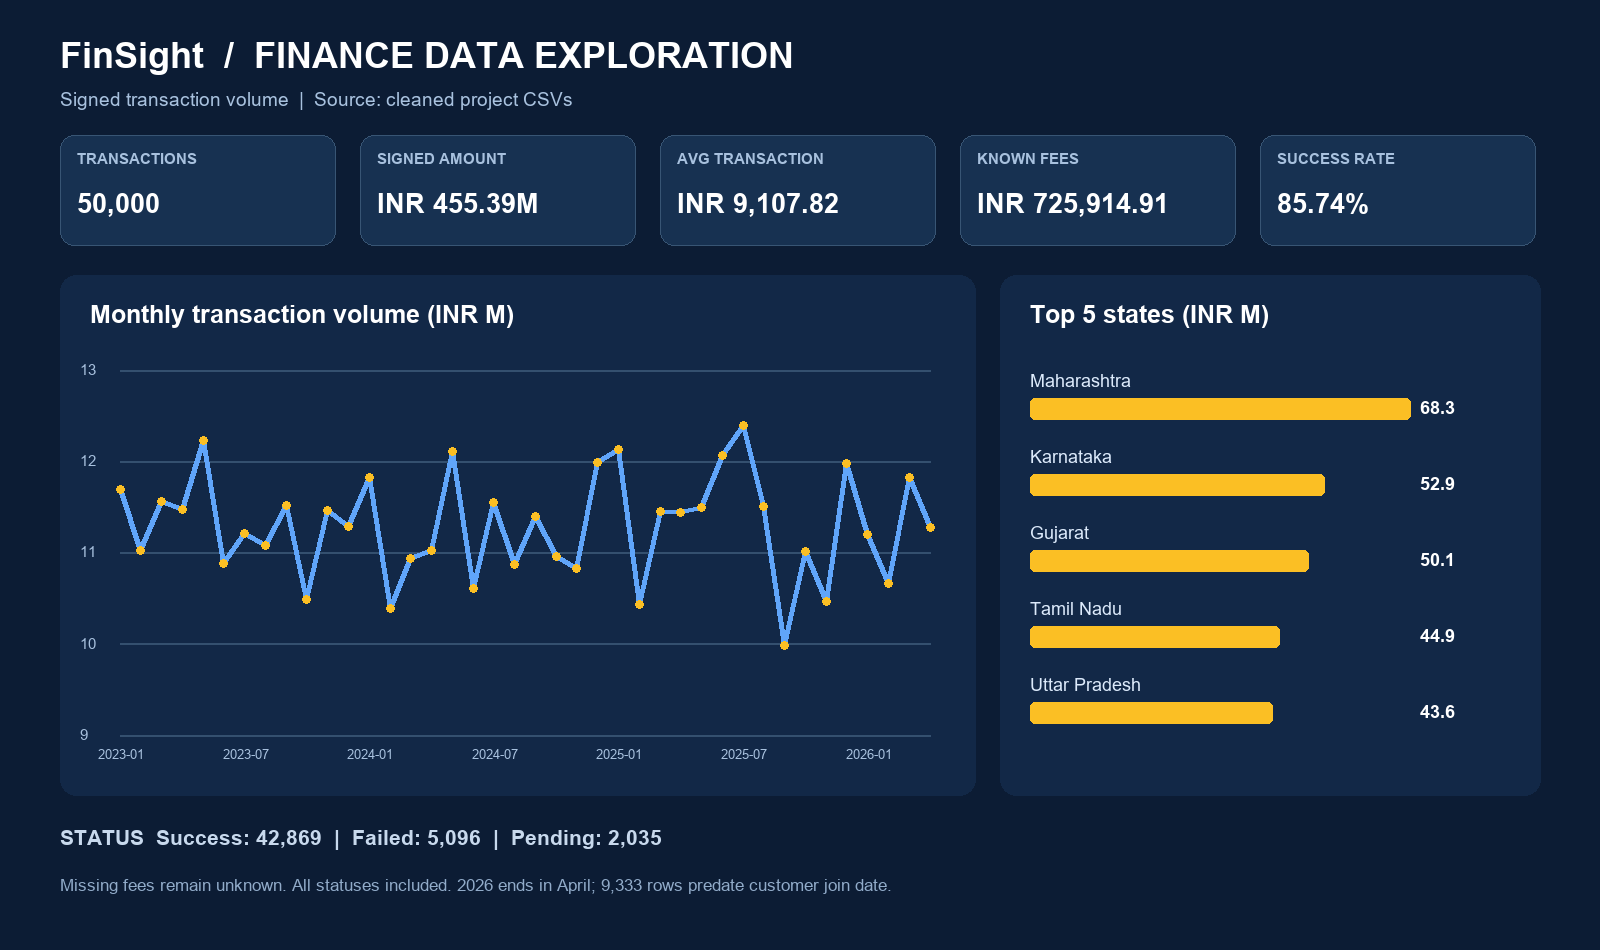

In [7]:
PNG_PATH = render(DB_PATH, OUTPUT / 'finance_summary.png')
print('PNG:', PNG_PATH)
Image.open(PNG_PATH)

## 5. Visualization تفاعلية بـ Plotly (اختياري)

لو Plotly متثبتة، الخلية الجاية تعرض الاتجاه الشهري والحالات وأعلى الولايات وأنواع المعاملات، وتحفظ HTML مستقل في `analysis/output/finance_analysis.html`. باقي الـ Notebook يشتغل حتى لو Plotly غير متاحة.


In [8]:
import importlib.util
if importlib.util.find_spec('plotly') is None:
    print('Plotly is optional. Install requirements.txt to generate the interactive HTML.')
else:
    import plotly.graph_objects as go
    from plotly.subplots import make_subplots
    with sqlite3.connect(DB_PATH) as db:
        status_df = pd.read_sql_query('SELECT * FROM v_status_breakdown', db)
        type_df = pd.read_sql_query('SELECT * FROM v_transaction_type ORDER BY total_amount_inr DESC', db)
    fig = make_subplots(rows=2, cols=2,
        specs=[[{'type':'xy'}, {'type':'domain'}], [{'type':'xy'}, {'type':'xy'}]],
        subplot_titles=('Monthly transaction volume (INR)', 'Transactions by status',
                        'Top five states (INR)', 'Transaction type amount (INR)'))
    fig.add_trace(go.Scatter(x=monthly['month'], y=monthly['total_amount_inr'],
        mode='lines+markers', name='Monthly volume', line_color='#60a5fa'), row=1, col=1)
    fig.add_trace(go.Pie(labels=status_df['transaction_status'], values=status_df['transactions'],
        hole=.6, name='Status'), row=1, col=2)
    fig.add_trace(go.Bar(y=top_states['state'][::-1], x=top_states['total_amount_inr'][::-1],
        orientation='h', name='States', marker_color='#fbbf24'), row=2, col=1)
    fig.add_trace(go.Bar(x=type_df['transaction_type'], y=type_df['total_amount_inr'],
        name='Transaction types', marker_color='#38bdf8'), row=2, col=2)
    fig.update_layout(template='plotly_dark', height=900, showlegend=False,
        title='FinSight | Cleaned finance data', paper_bgcolor='#0c1c34', plot_bgcolor='#122847')
    fig.write_html(OUTPUT / 'finance_analysis.html', include_plotlyjs=True, full_html=True)
    fig.show()
    print('Interactive HTML:', OUTPUT / 'finance_analysis.html')

Interactive HTML: E:\BI Projects\Power BI - Finance Analysis\analysis\output\finance_analysis.html


## 6. تحققات نهائية وتفسير بزنس

نتأكد من عدد المعاملات والعلاقة مع العملاء وتطابق مبالغ SQL مع تقرير التنظيف. الـ 9,333 معاملة قبل `join_date` تحتاج مراجعة تعريف تاريخ الانضمام، و2026 لحد أبريل فقط؛ أي مقارنة سنوية لازم تكون لنفس الفترة.


In [9]:
assert quality['clean_transaction_rows'] == 50_000
assert quality['orphan_transactions'] == 0
assert quality['blank_fees'] == 23
assert quality['negative_amount_rows'] == 8
assert round(float(quality['total_amount_signed_inr']), 2) == float(overview.loc[0, 'total_amount_inr'])
assert round(float(quality['known_fees_inr']), 2) == float(overview.loc[0, 'known_fees_inr'])
assert len(monthly) == 40
print('Checks passed: unique transactions, joins, missing fees, signed amounts, KPI reconciliation, 40 months.')

Checks passed: unique transactions, joins, missing fees, signed amounts, KPI reconciliation, 40 months.


## 7. الخلاصة والخطوة التالية

التحليل الناتج عن هذه الـ Notebook مستقل عن الـ Power BI model الحالي. التقرير الحالي يحوّل `amount` لقيمة مطلقة ويملأ الرسوم الفارغة بـ `14.52`، لذلك لا نتوقع تطابق أرقامه مع هذه النسخة قبل تحديث Power Query عن قصد. من منظور بزنس: اعرض `Total Amount` كحجم معاملات، واعتبر `Known Fees` رسومًا مرصودة فقط، وافحص تواريخ الانضمام غير المنطقية قبل استخدامها في أي قصة عن عمر العميل.
